In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler, FunctionTransformer

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve, auc,precision_score, recall_score, matthews_corrcoef,log_loss
from sklearn.compose import ColumnTransformer

from sklearn import set_config
from sklearn import svm,metrics
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance

#from tensorflow.keras import models, layers, Input

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)
from scripts.Function_group import model_eval, ModelTuner


In [2]:
# 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
set_config(transform_output="pandas")

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
df1 = pd.read_csv(os.path.join(project_root, 'data', 'raw', 'big_data_set1_f.csv'),encoding='cp949')
df2 = pd.read_csv(os.path.join(project_root, 'data', 'raw', 'big_data_set2_f.csv'),encoding='cp949')
df3 = pd.read_csv(os.path.join(project_root, 'data', 'raw', 'big_data_set3_f.csv'),encoding='cp949')

In [4]:
df1 = df1.rename(columns={'ENCODED_MCT': '가맹점구분번호','MCT_BSE_AR':'가맹점주소','MCT_NM':'가맹점명','MCT_BRD_NUM':'브랜드구분코드',
                         'MCT_SIGUNGU_NM':'가맹점지역','HPSN_MCT_ZCD_NM':'업종','HPSN_MCT_BZN_CD_NM':'상권','ARE_D':'개설일','MCT_ME_D':'폐업일'})

In [5]:
df2 = df2.rename(columns={'ENCODED_MCT':'가맹점구분번호','TA_YM':'기준년월','MCT_OPE_MS_CN':'가맹점 운영개월수 구간','RC_M1_SAA':'매출금액 구간',
                         'RC_M1_TO_UE_CT':'매출건수 구간','RC_M1_UE_CUS_CN':'유니크 고객 수 구간','RC_M1_AV_NP_AT':'객단가 구간','APV_CE_RAT':'취소율 구간',
                         'DLV_SAA_RAT':'배달매출금액 비율','M1_SME_RY_SAA_RAT':'동일 업종 매출금액 비율','M1_SME_RY_CNT_RAT':'동일 업종 매출건수 비율',
                         'M12_SME_RY_SAA_PCE_RT':'동일 업종 내 매출 순위 비율','M12_SME_BZN_SAA_PCE_RT':'동일 상권 내 매출 순위 비율',
                         'M12_SME_RY_ME_MCT_RAT':'동일 업종 내 해지 가맹점 비중','M12_SME_BZN_ME_MCT_RAT':'동일 상권 내 해지 가맹점 비중'})

In [6]:
df3 = df3.rename(columns={'ENCODED_MCT':'가맹점구분번호','TA_YM':'기준년월','M12_MAL_1020_RAT':'남성 20대이하 고객 비중',
                         'M12_MAL_30_RAT':'남성 30대 고객 비중','M12_MAL_40_RAT':'남성 40대 고객 비중','M12_MAL_50_RAT':'남성 50대 고객 비중',
                         'M12_MAL_60_RAT':'남성 60대이상 고객 비중','M12_FME_1020_RAT':'여성 20대이하 고객 비중','M12_FME_30_RAT':'여성 30대 고객 비중',
                         'M12_FME_40_RAT':'여성 40대 고객 비중','M12_FME_50_RAT':'여성 50대 고객 비중','M12_FME_60_RAT':'여성 60대이상 고객 비중',
                         'MCT_UE_CLN_REU_RAT':'재방문 고객 비중','MCT_UE_CLN_NEW_RAT':'신규 고객 비중','RC_M1_SHC_RSD_UE_CLN_RAT':'거주 이용 고객 비율',
                         'RC_M1_SHC_WP_UE_CLN_RAT':'직장 이용 고객 비율','RC_M1_SHC_FLP_UE_CLN_RAT':'유동인구 이용 고객 비율'})

In [7]:
#결측치 제거
df2.replace(-999999.9, 0, inplace=True)
df3.replace(-999999.9, 0, inplace=True)

In [8]:
df1.isnull().sum()

가맹점구분번호       0
가맹점주소         0
가맹점명          0
브랜드구분코드    3643
가맹점지역         0
업종            0
상권         1047
개설일           0
폐업일        4058
dtype: int64

In [9]:
df1["target"] = np.where(df1["폐업일"].isnull(),0,1)
df1["brand"] = np.where(df1['브랜드구분코드'].isnull(),0,1)
df1["place"] = np.where(df1['상권'].isnull(),0,1)
df1 = df1.drop(columns = ['가맹점구분번호','브랜드구분코드','상권','폐업일'])


In [10]:
df1.isnull().sum()

가맹점주소     0
가맹점명      0
가맹점지역     0
업종        0
개설일       0
target    0
brand     0
place     0
dtype: int64

In [11]:
X = df1.drop(columns = ['target'])
y = df1["target"]

In [12]:
'''
tuner = ModelTuner(X, y)

#2. LightGBM 모델 튜닝 및 평가
tuner.run(model_name='lgbm', tune_evals=50)

#3. XGBoost 모델 튜닝 및 평가
tuner.run(model_name='xgb', tune_evals=50)
'''

"\ntuner = ModelTuner(X, y)\n\n#2. LightGBM 모델 튜닝 및 평가\ntuner.run(model_name='lgbm', tune_evals=50)\n\n#3. XGBoost 모델 튜닝 및 평가\ntuner.run(model_name='xgb', tune_evals=50)\n"

### 인코딩

In [13]:
#학습, 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # 숫자형 컬럼은 StandardScaling
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
    ])
#주의: 테스트 셋에서 학습 데이터에 없는 값들이 무시될 수 있음 handle_unknown='ignore' 없는 것도 적용해 볼것
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)#학습, 검증 데이터 셋 분리

In [14]:
X_train.shape

(3348, 5319)

### Logistic Regression

--- Logistic Regression 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



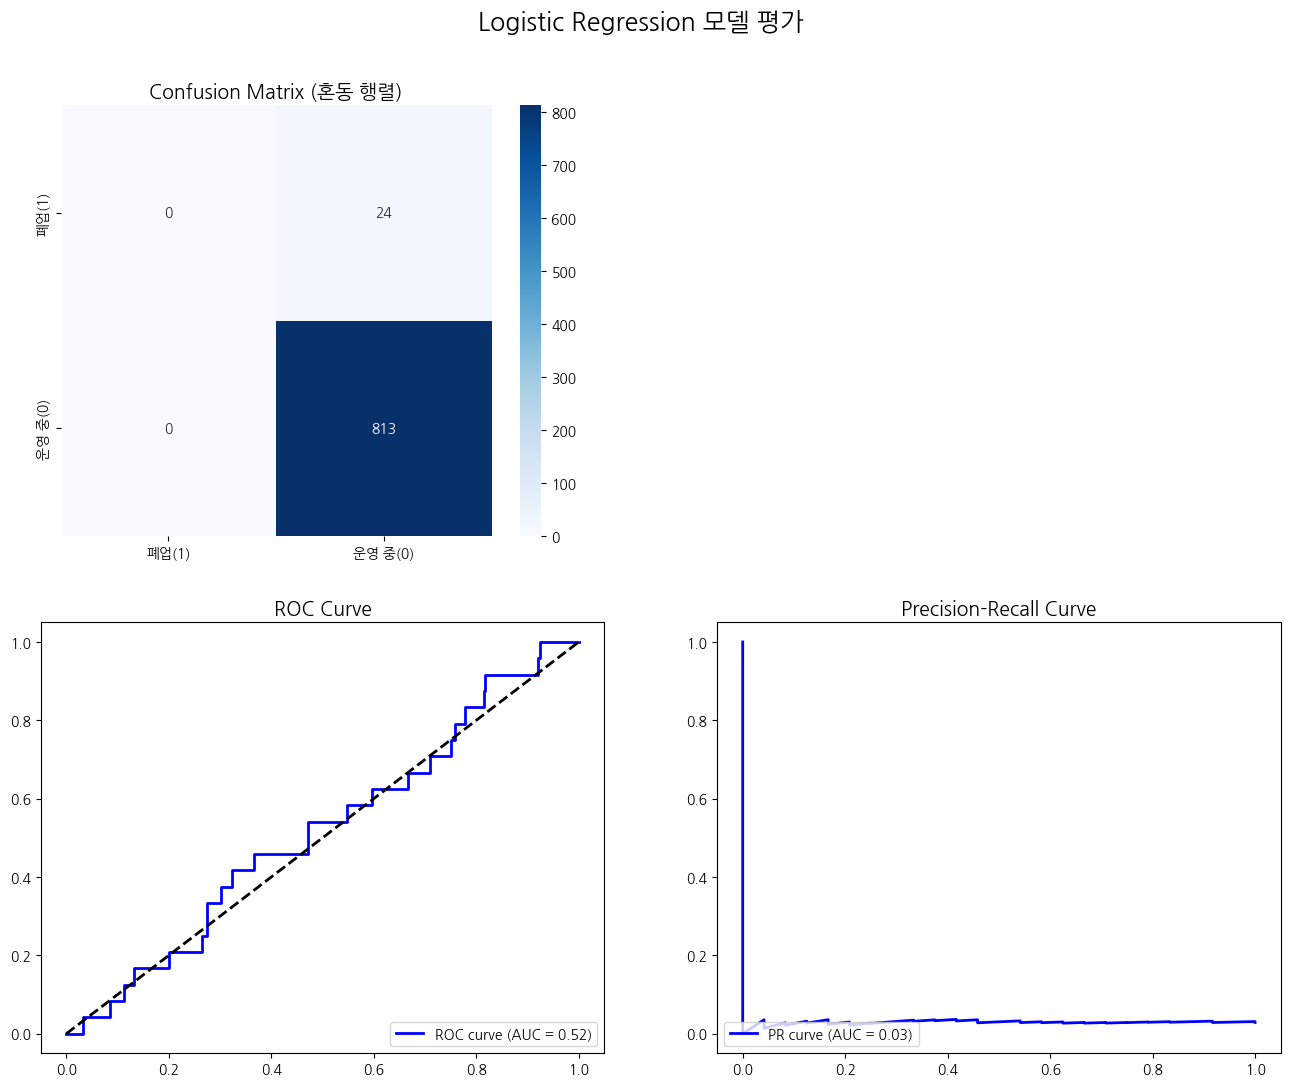

In [35]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train,y_train)

model_eval(model,"Logistic Regression",X_test,y_test)

In [ ]:
ModelTuner('logistic',X_train, X_test,y_train,y_test).run()

--- logistic 모델의 하이퍼파라미터 튜닝 시작 ---
 10%|███▋                                 | 5/50 [02:14<21:07, 28.17s/trial, best loss: -0.6014285714285714]

### Gaussian Naive Bayes

--- Gaussian Naive Bayes 모델 평가 ---
정확도(Accuracy): 0.5424
정밀도(Precision): 0.0264
재현율(Recall): 0.4167
F1 점수(F1 Score): 0.0496
매튜 상관 계수(MCC): -0.0125



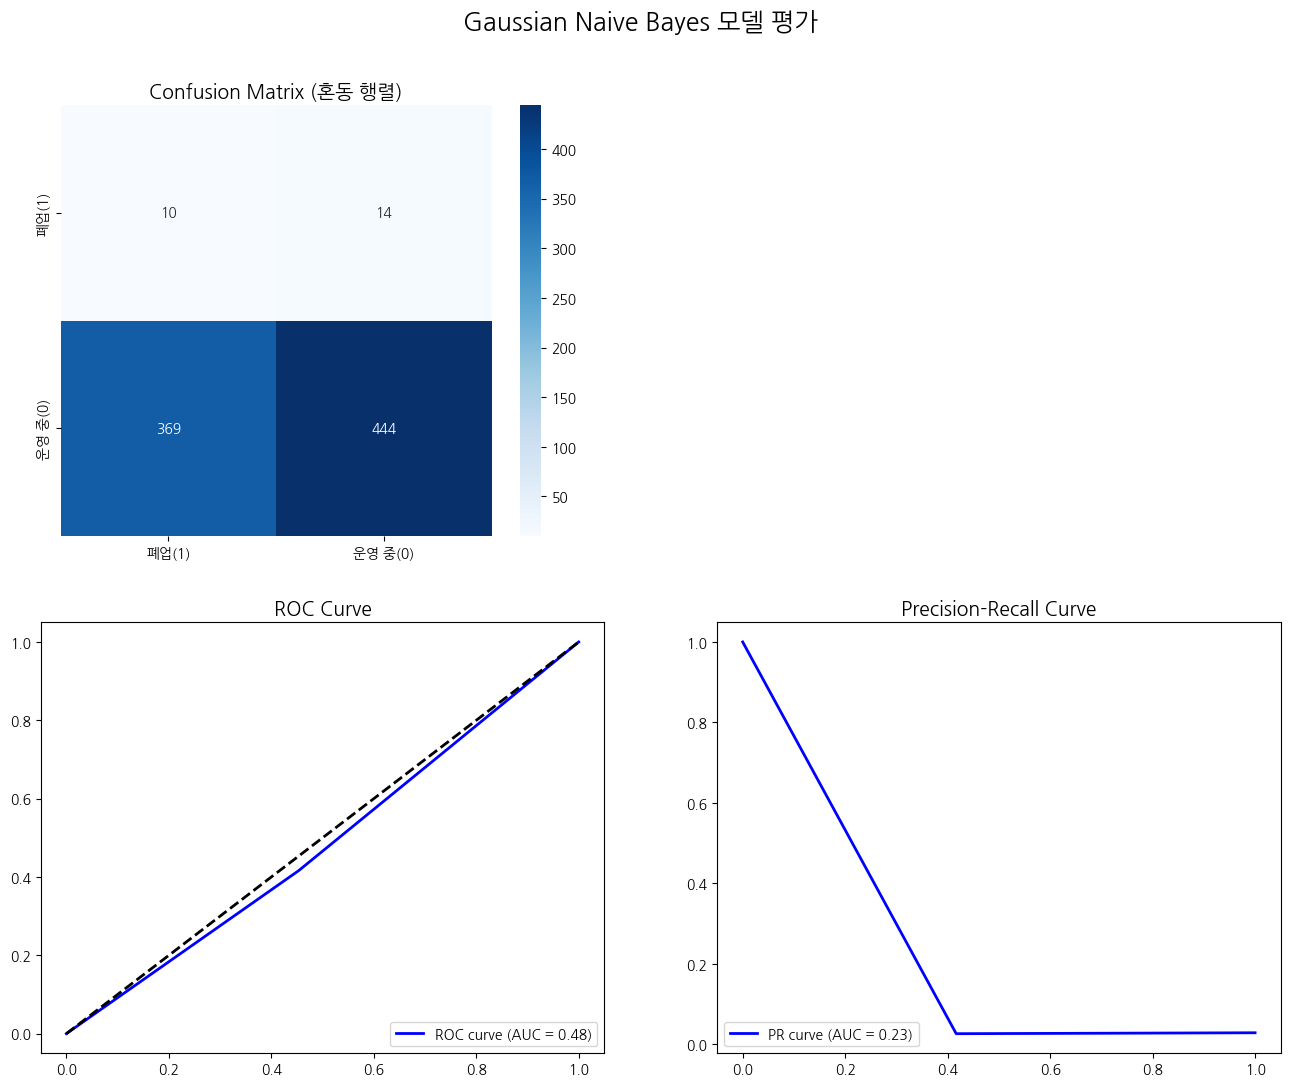

In [15]:
# Gaussian Naive Bayes
model=GaussianNB()
model.fit(X_train.toarray(),y_train)

#가우시안은 X 데이터에 .toarray() 붙이기
model_eval(model,"Gaussian Naive Bayes",X_test.toarray(),y_test)

--- gnb 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████| 50/50 [00:29<00:00,  1.72trial/s, best loss: -0.49857142857142855]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'var_smoothing': np.float64(4.239462667878075e-09)}
##############################

최종 모델 학습 완료.
--- GNB 모델 평가 ---
정확도(Accuracy): 0.5424
정밀도(Precision): 0.0264
재현율(Recall): 0.4167
F1 점수(F1 Score): 0.0496
매튜 상관 계수(MCC): -0.0125



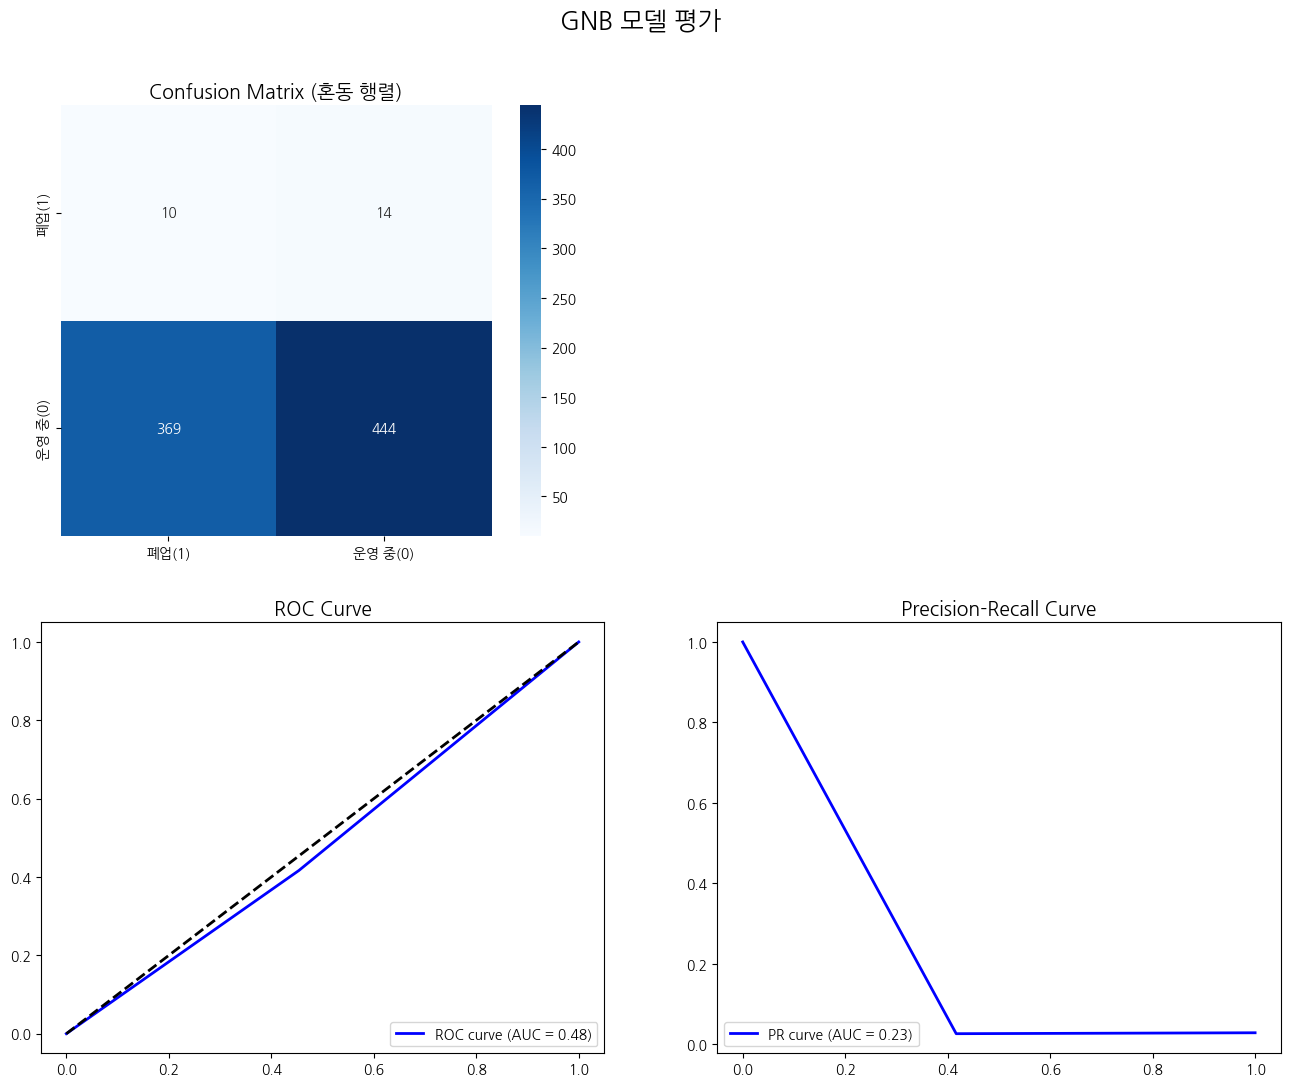

In [16]:
ModelTuner('gnb',X_train, X_test,y_train,y_test).run()

### KNN(K-Nearest Neighbours)

--- K-Nearest Neighbours 모델 평가 ---
정확도(Accuracy): 0.9689
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): -0.0084



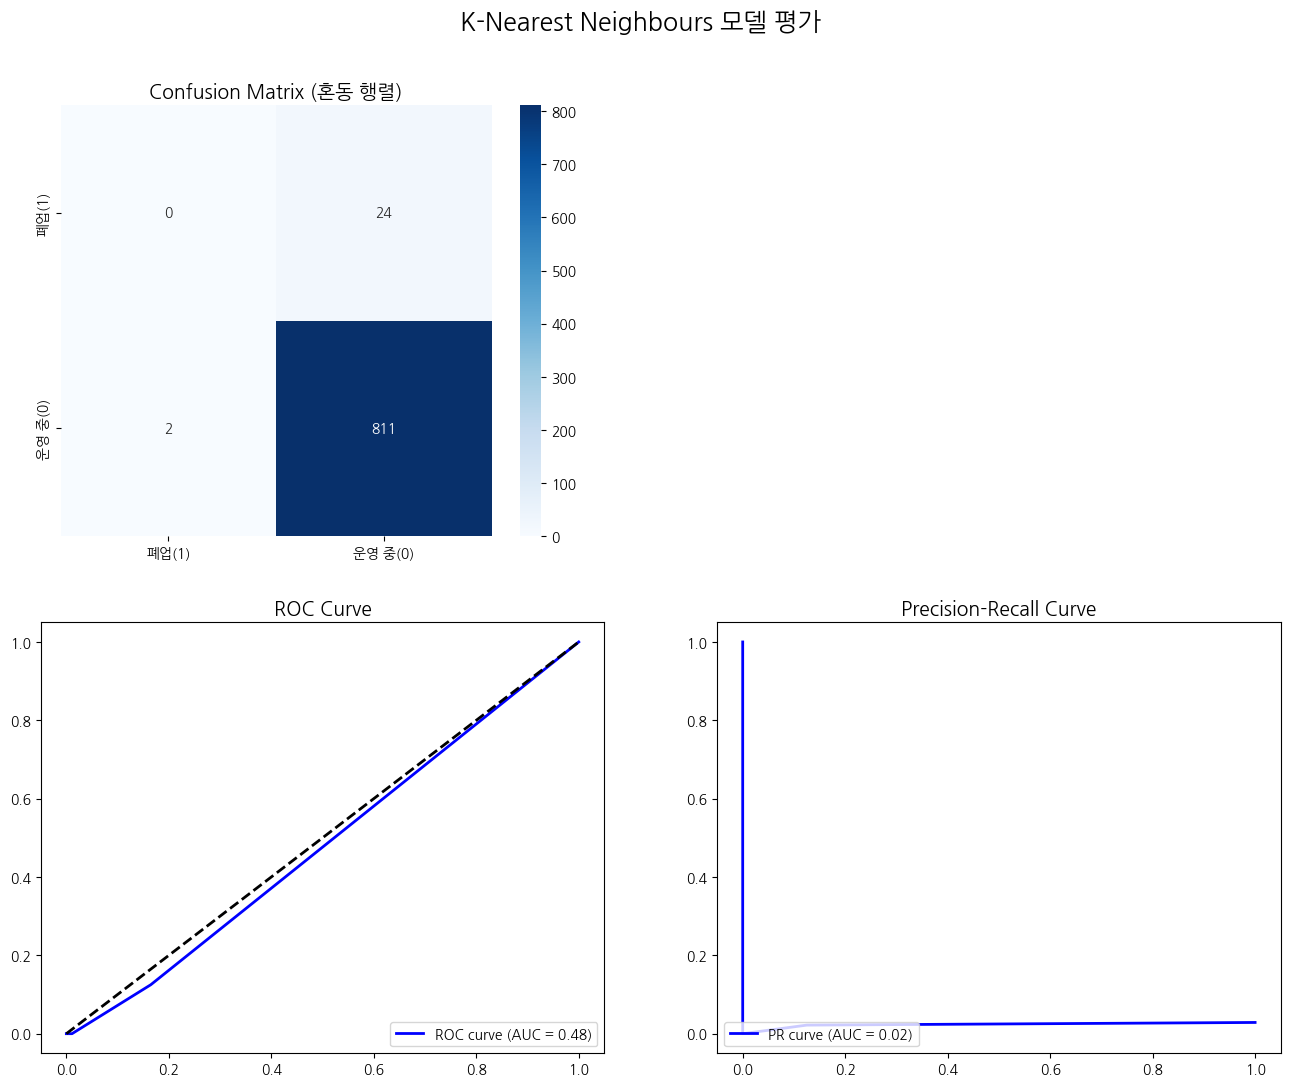

In [17]:
#K-Nearest Neighbours(KNN)
model=KNeighborsClassifier() 
model.fit(X_train,y_train)

model_eval(model,"K-Nearest Neighbours",X_test,y_test)

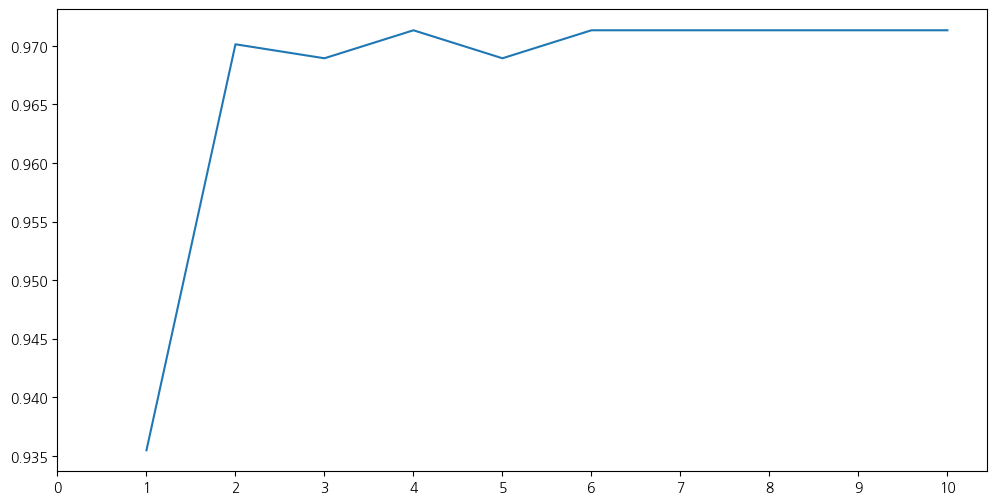

Accuracies for different values of n are: [0.93548387 0.97013142 0.96893668 0.97132616 0.96893668 0.97132616
 0.97132616 0.97132616 0.97132616 0.97132616] with the max value as  0.9713261648745519


In [18]:
#KNN 모델에서 N-neighbours 수를 늘려가며 정확도를 계산
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i) 
    model.fit(X_train,y_train)
    prediction=model.predict(X_test)
    score = pd.Series([metrics.accuracy_score(prediction,y_test)])
    a = pd.concat([a, score], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

--- knn 모델의 하이퍼파라미터 튜닝 시작 ---
100%|██████████████████████████████████| 50/50 [00:07<00:00,  6.38trial/s, best loss: -0.019523809523809523]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'metric': 'minkowski', 'n_neighbors': np.float64(3.0), 'weights': 'uniform'}
##############################

최종 모델 학습 완료.
--- KNN 모델 평가 ---
정확도(Accuracy): 0.9689
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): -0.0084



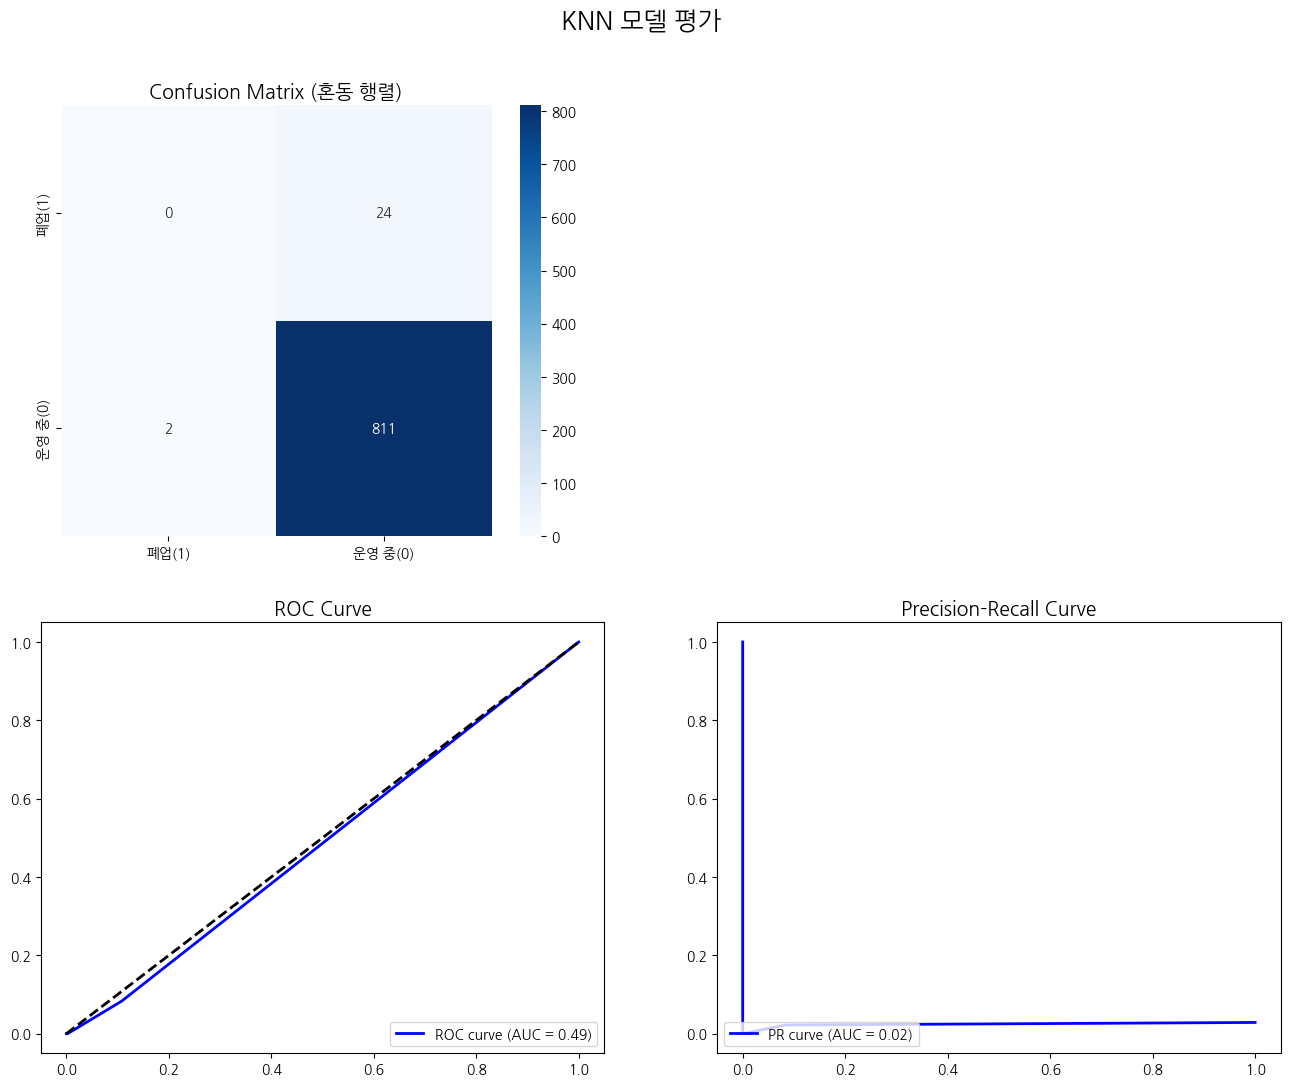

In [19]:
ModelTuner('knn',X_train, X_test,y_train,y_test).run()

### Support Vector Machine

--- Linear Support Vector Machine 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



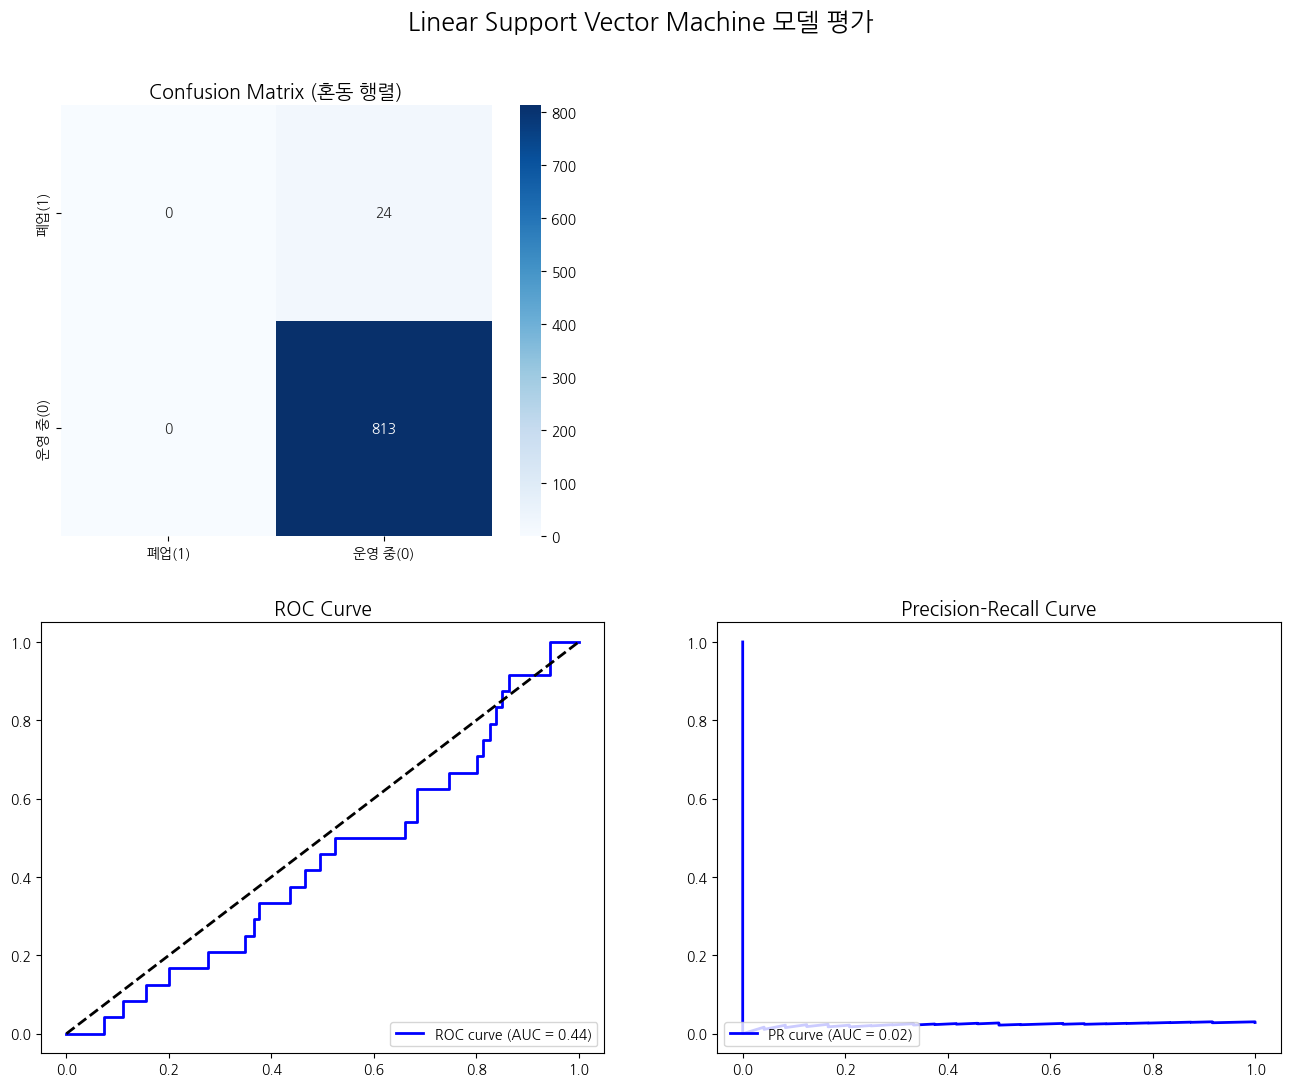

In [20]:
#Linear Support Vector Machine(linear-SVM)
model=svm.SVC(probability=True,kernel='linear',C=0.1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Linear Support Vector Machine",X_test,y_test)

--- svc_linear 모델의 하이퍼파라미터 튜닝 시작 ---
100%|████████████████████████████████████| 50/50 [01:53<00:00,  2.27s/trial, best loss: -0.6028571428571429]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'C': np.float64(0.010411496798330349), 'class_weight': 'balanced'}
##############################

최종 모델 학습 완료.
--- SVC_LINEAR 모델 평가 ---
정확도(Accuracy): 0.4205
정밀도(Precision): 0.0305
재현율(Recall): 0.6250
F1 점수(F1 Score): 0.0583
매튜 상관 계수(MCC): 0.0134



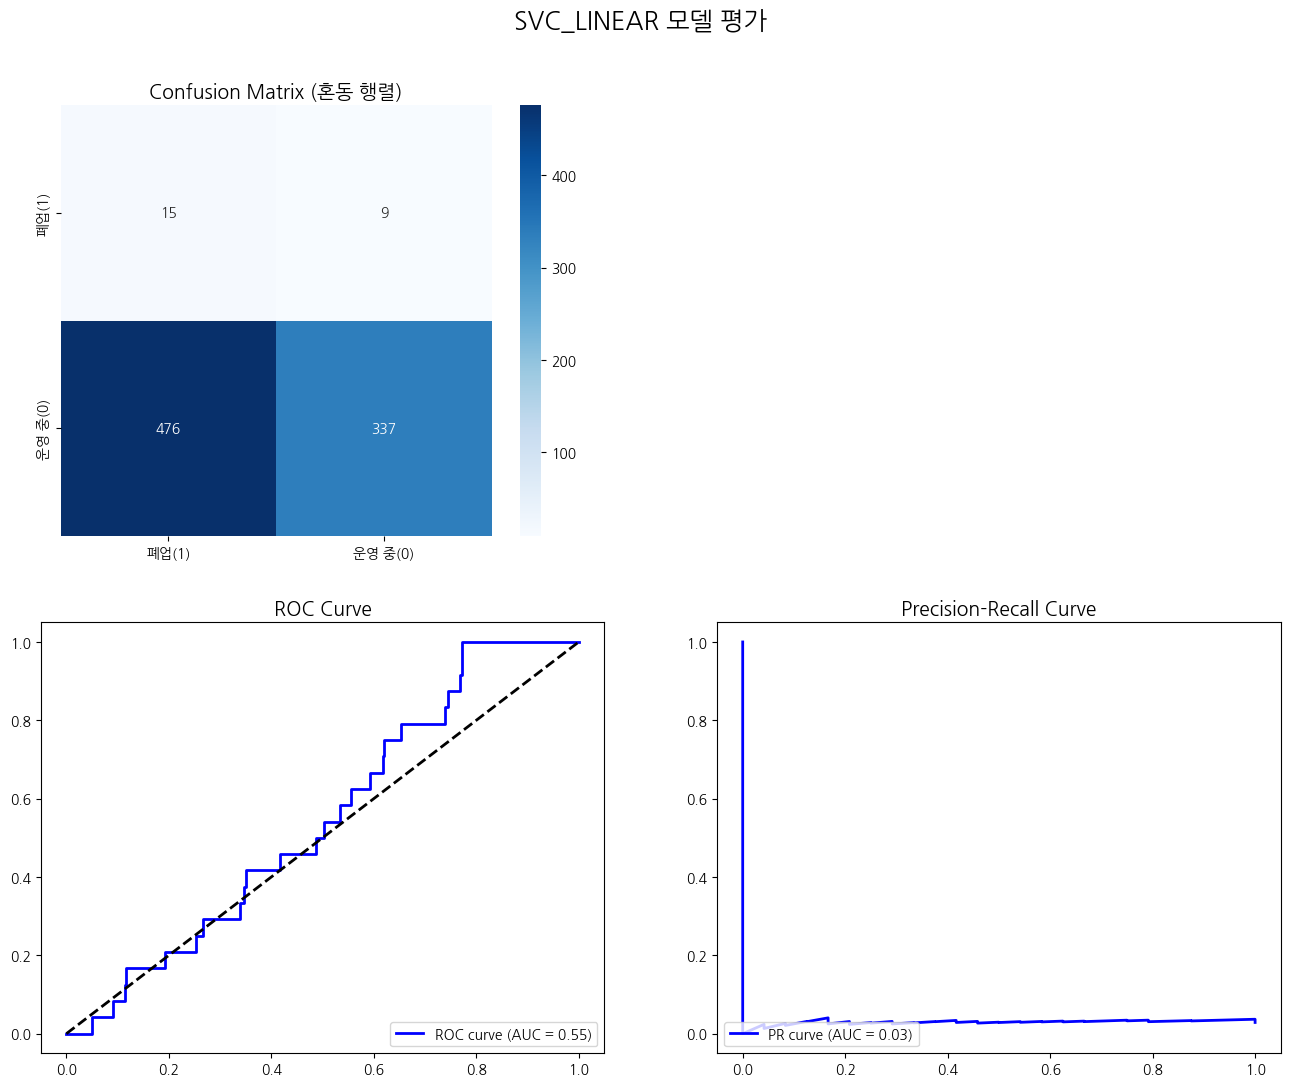

In [21]:
ModelTuner('svc_linear',X_train, X_test,y_train,y_test).run()

--- Radial Support Vector Machines 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



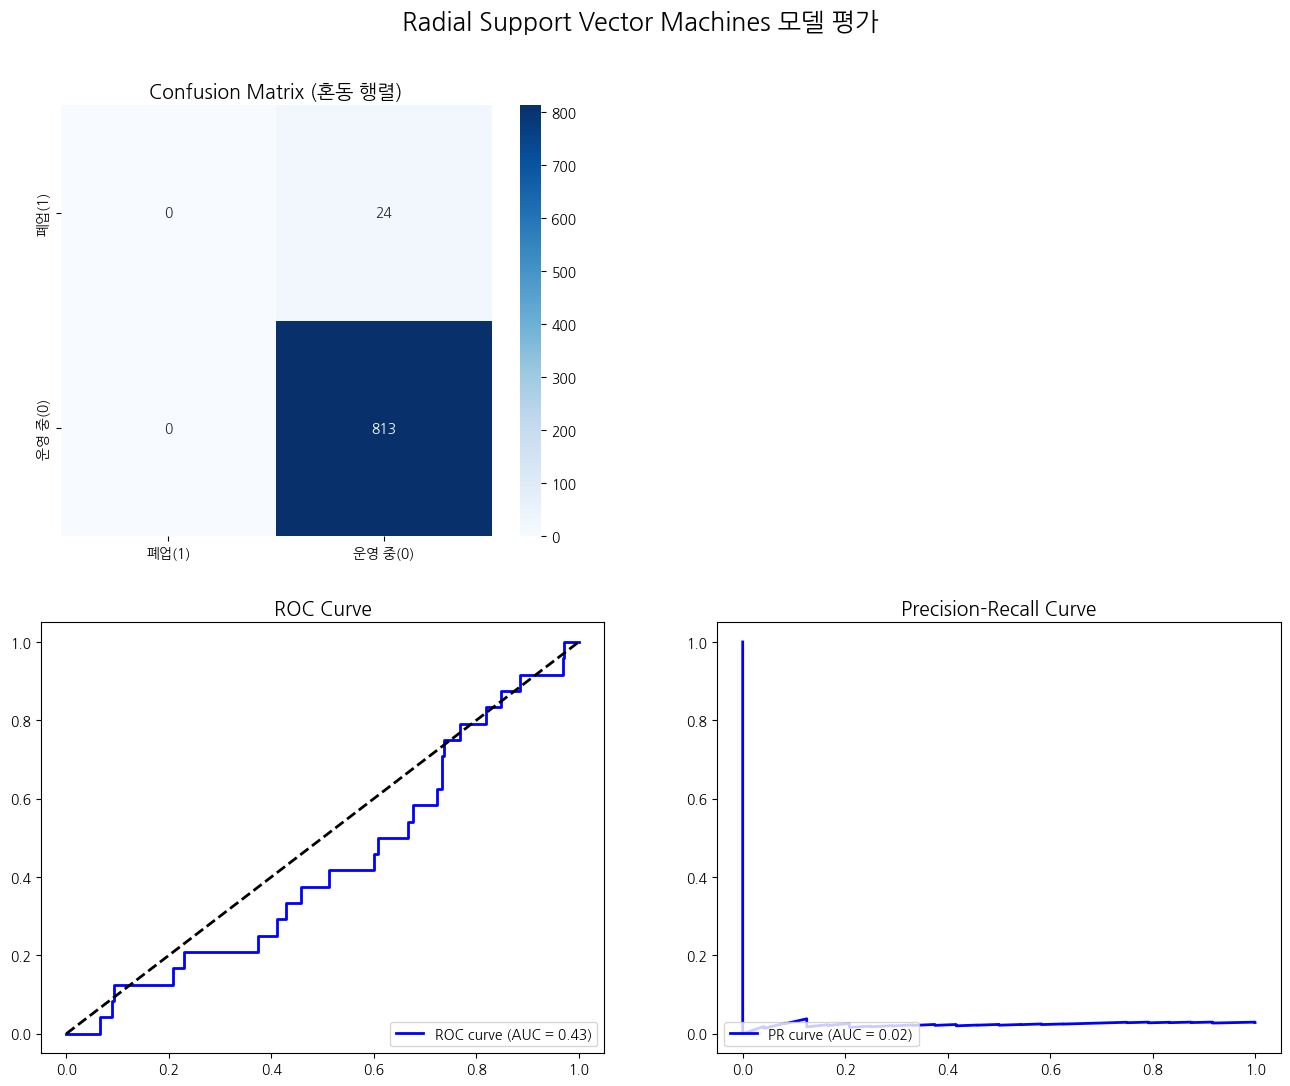

In [23]:
#Radial Support Vector Machines(rbf-SVM)
model=svm.SVC(probability=True,kernel='rbf',C=1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Radial Support Vector Machines",X_test,y_test)

--- svc_rbf 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [02:21<00:00,  2.83s/trial, best loss: -1.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'C': np.float64(0.027813730376409208), 'class_weight': 'balanced', 'gamma': np.float64(0.00018607657136529177)}
##############################

최종 모델 학습 완료.
--- SVC_RBF 모델 평가 ---
정확도(Accuracy): 0.0287
정밀도(Precision): 0.0287
재현율(Recall): 1.0000
F1 점수(F1 Score): 0.0557
매튜 상관 계수(MCC): 0.0000



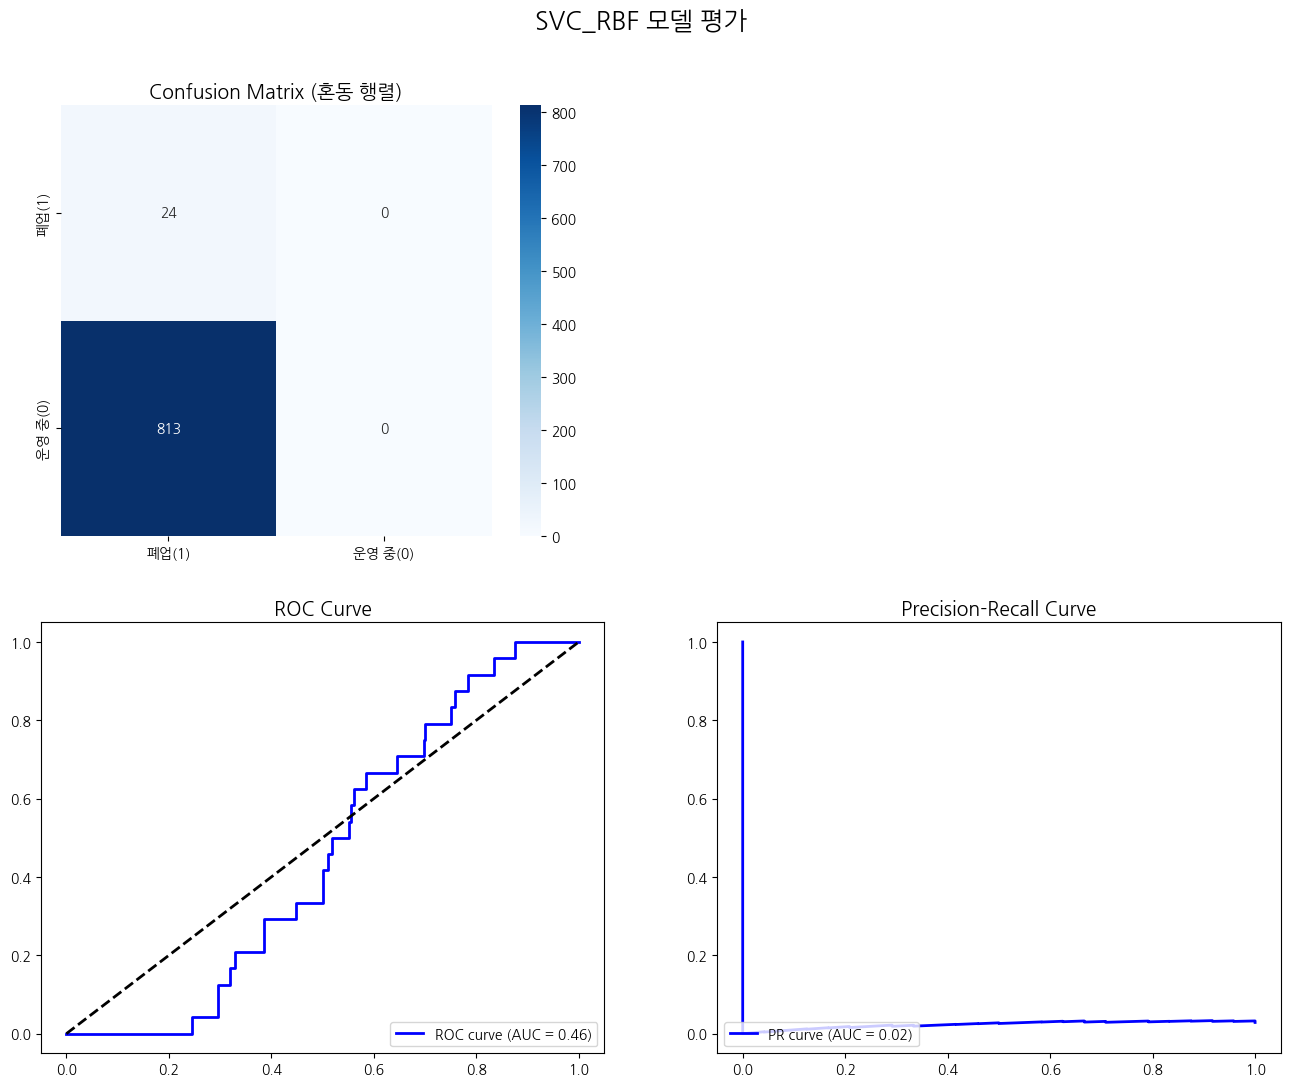

In [24]:
ModelTuner('svc_rbf',X_train, X_test,y_train,y_test).run()

### Light Gradient Boosting Machine

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Info] Number of positive: 82, number of negative: 2596
[LightGBM] [Info] Total Bins 323
[LightGBM] [Info] Number of data points in the train set: 2678, number of used features: 34
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rou

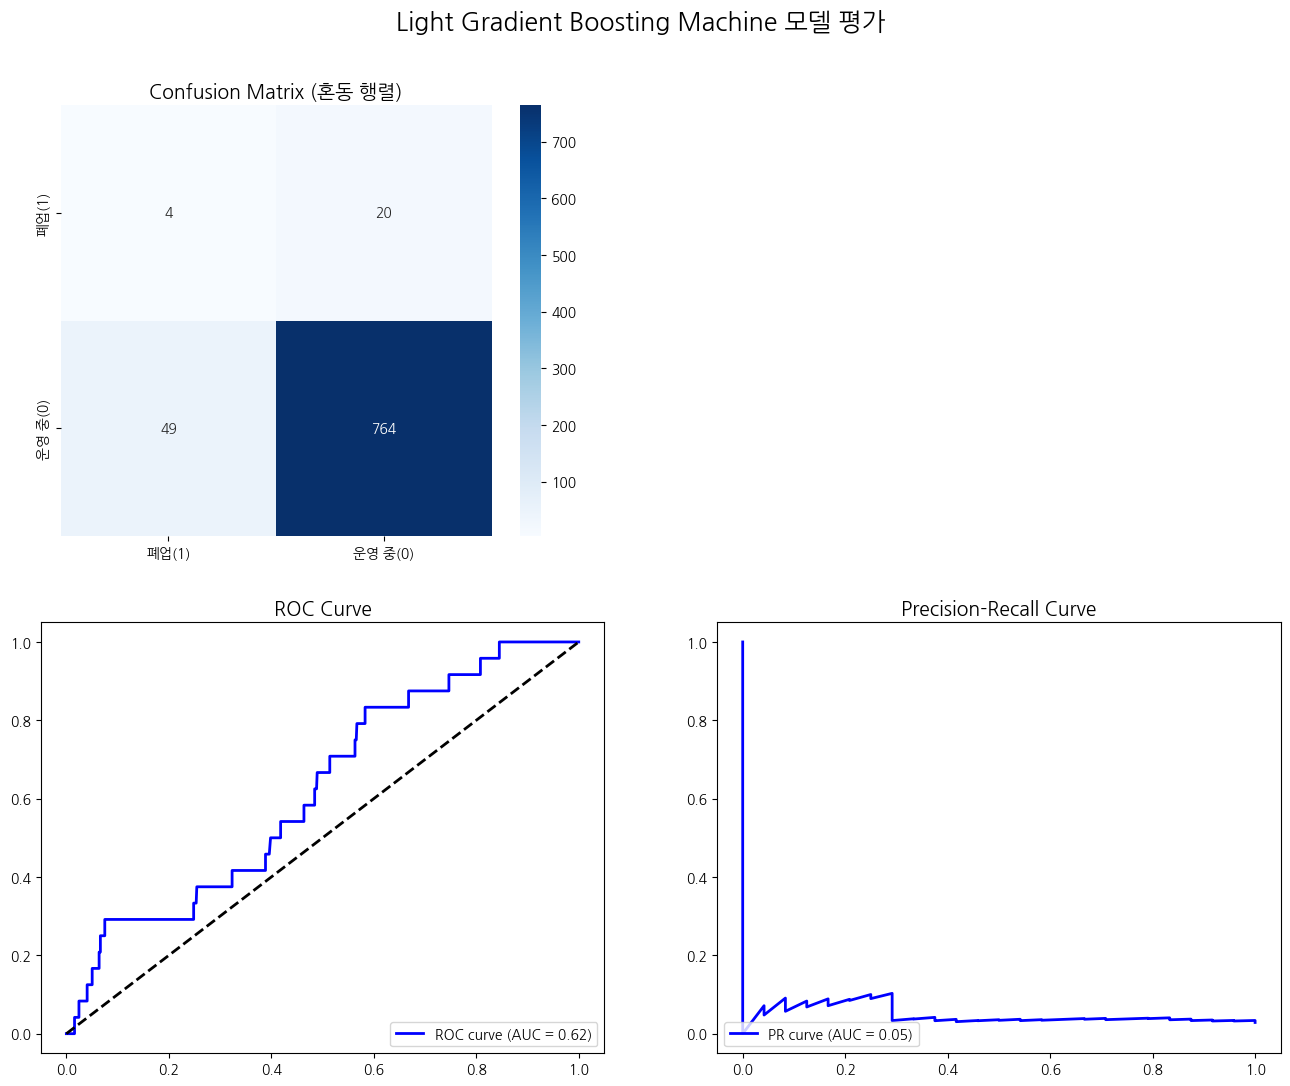

In [15]:
lgb_model = LGBMClassifier(
    device='cuda',
    n_estimators=500,
    learning_rate=0.05,
    class_weight = "balanced", #가중치추가
    subsample=0.8,
    colsample_bytree=0.8,
    min_gain_to_split=0.05,
    random_state=42,
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)]
    ,callbacks=[lgbm.early_stopping(stopping_rounds=50, verbose=-1)]
)

model_eval(lgb_model,"Light Gradient Boosting Machine",X_test,y_test)

--- lgbm 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [03:36<00:00,  4.33s/trial, best loss: -0.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'colsample_bytree': np.float64(0.7936739623353964), 'learning_rate': np.float64(0.02639565625679032), 'max_depth': np.float64(12.0), 'min_child_samples': np.float64(30.0), 'n_estimators': np.float64(1600.0), 'num_leaves': np.float64(105.0), 'reg_alpha': np.float64(0.8839266254726155), 'reg_lambda': np.float64(0.620118997676641), 'subsample': np.float64(0.9254621630561151)}


최종 모델 학습 완료.
--- LGBM 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



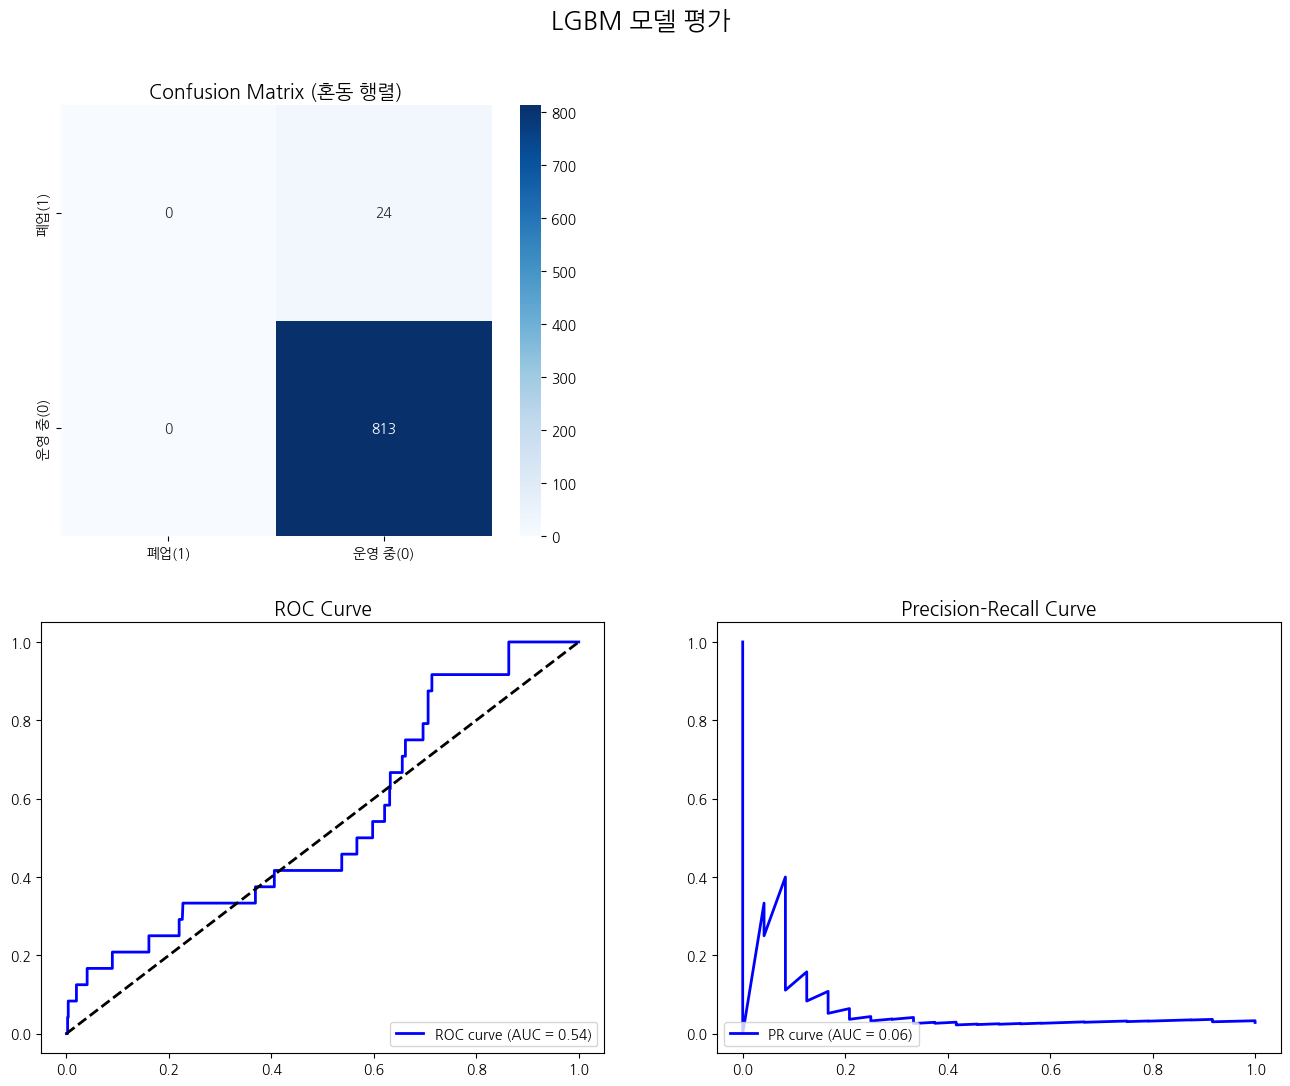

In [15]:
ModelTuner('lgbm',X_train, X_test,y_train,y_test).run()

### Exreme Gradient Boosting

--- Exreme Gradient Boosting 모델 평가 ---
정확도(Accuracy): 0.9510
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): -0.0247



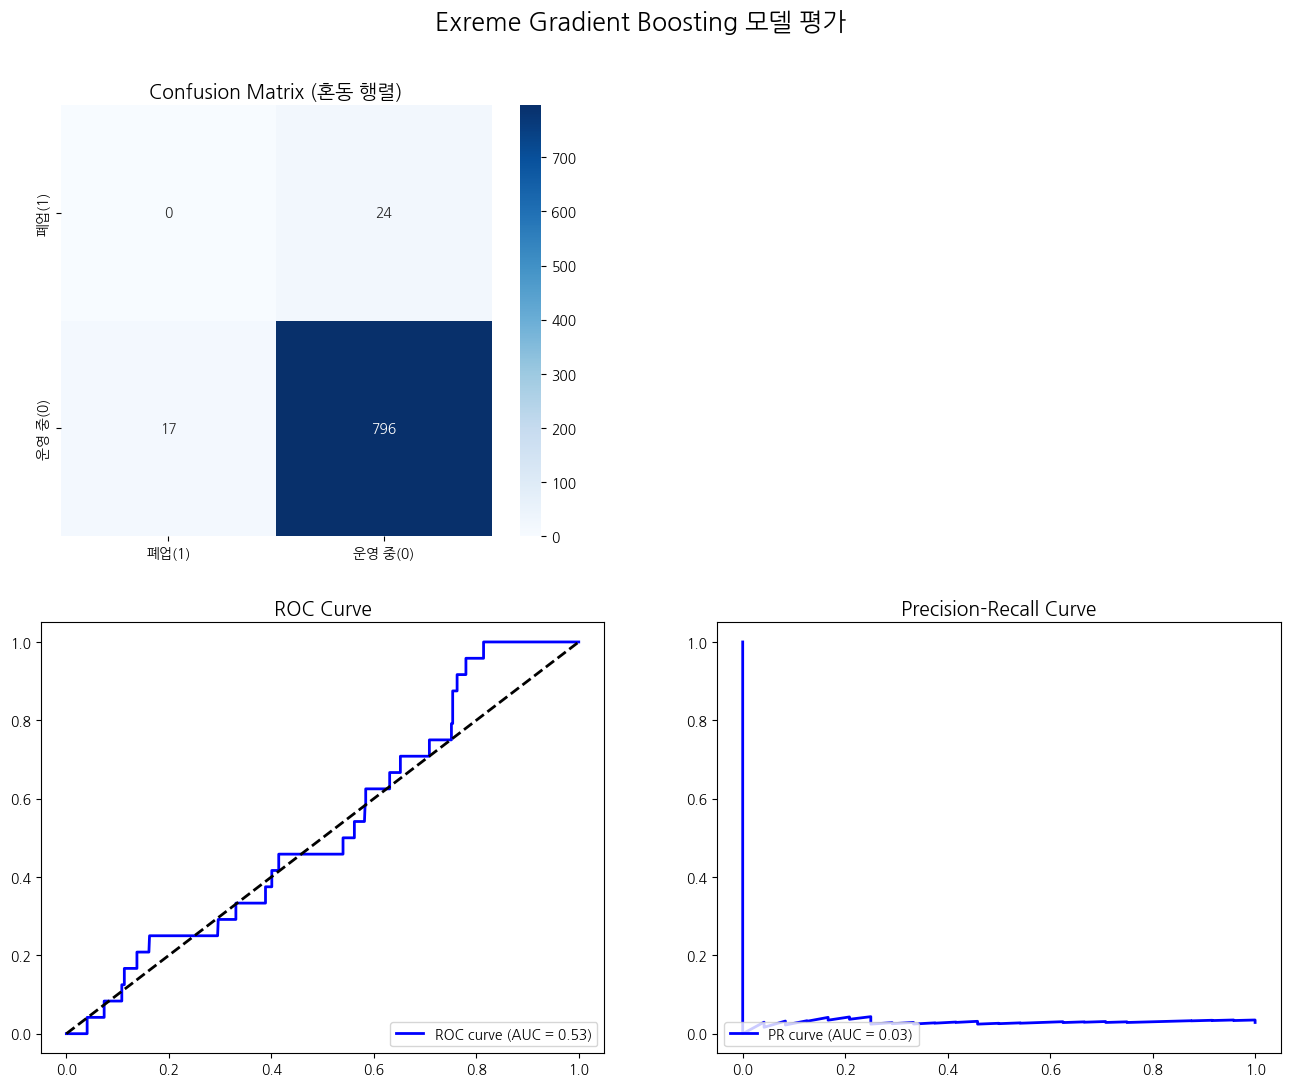

In [16]:
xgb_model = XGBClassifier(tree_method = "hist", device = "cuda",
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    early_stopping_rounds=50                      
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False
)

model_eval(xgb_model,"Exreme Gradient Boosting",X_test,y_test)

--- xgb 모델의 하이퍼파라미터 튜닝 시작 ---
100%|████████████████████████████████████| 50/50 [06:09<00:00,  7.39s/trial, best loss: -0.6514285714285715]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'colsample_bytree': np.float64(0.7784771204070735), 'gamma': np.float64(0.49343954900322046), 'learning_rate': np.float64(0.021573603699882794), 'max_depth': np.float64(3.0), 'min_child_weight': np.float64(9.0), 'n_estimators': np.float64(100.0), 'scale_pos_weight': np.float64(37.48994864253271), 'subsample': np.float64(0.8318352683200956)}


최종 모델 학습 완료.
--- XGB 모델 평가 ---
정확도(Accuracy): 0.3692
정밀도(Precision): 0.0351
재현율(Recall): 0.7917
F1 점수(F1 Score): 0.0671
매튜 상관 계수(MCC): 0.0518



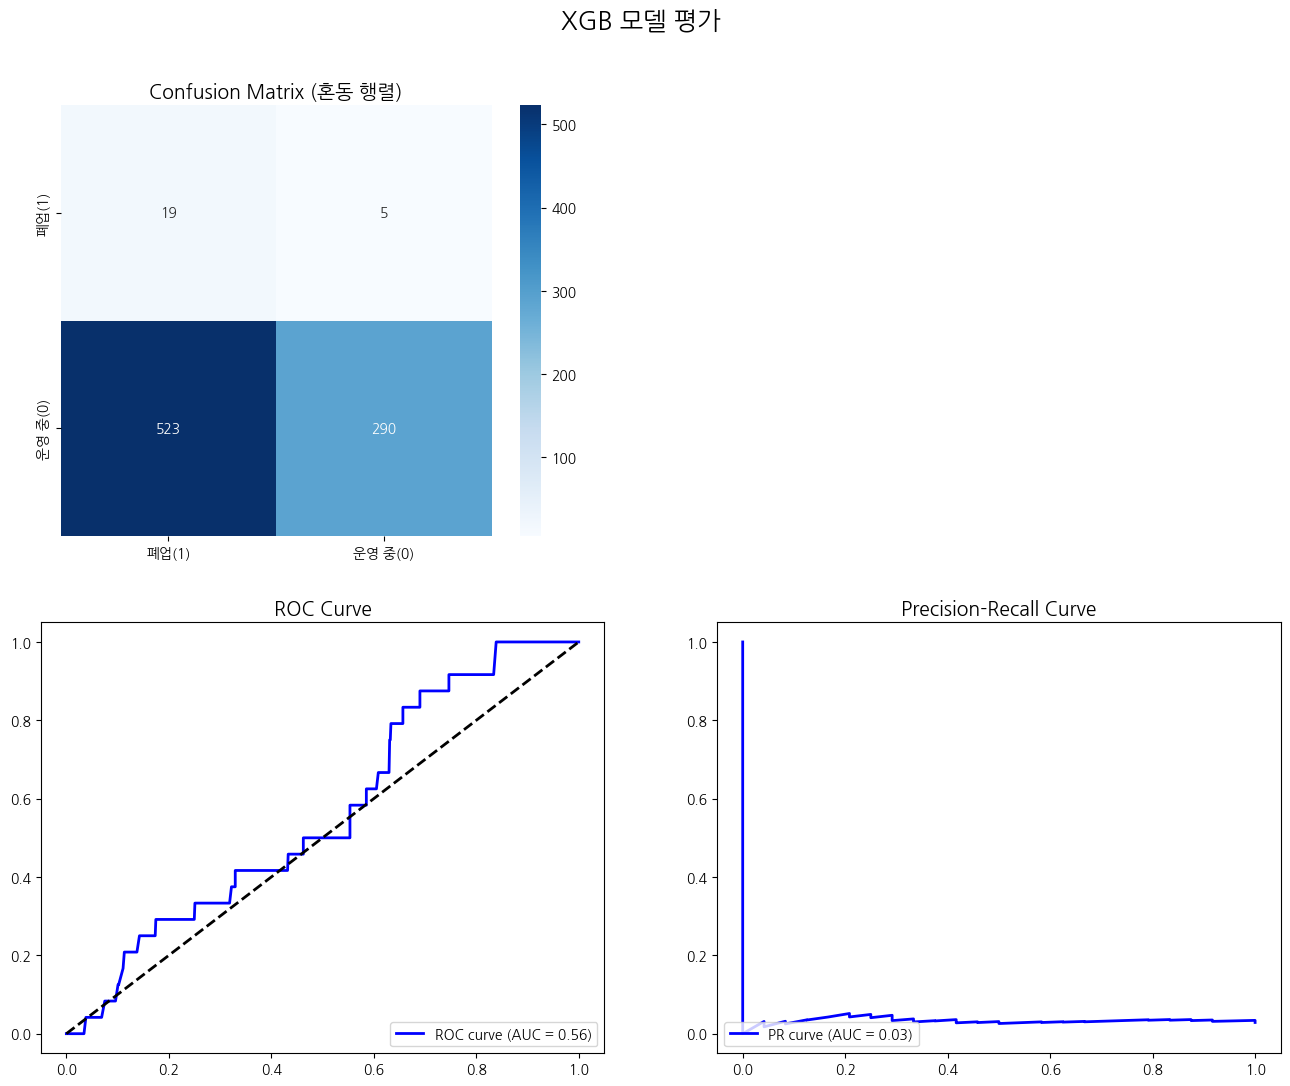

In [17]:
ModelTuner('xgb',X_train, X_test,y_train,y_test).run()

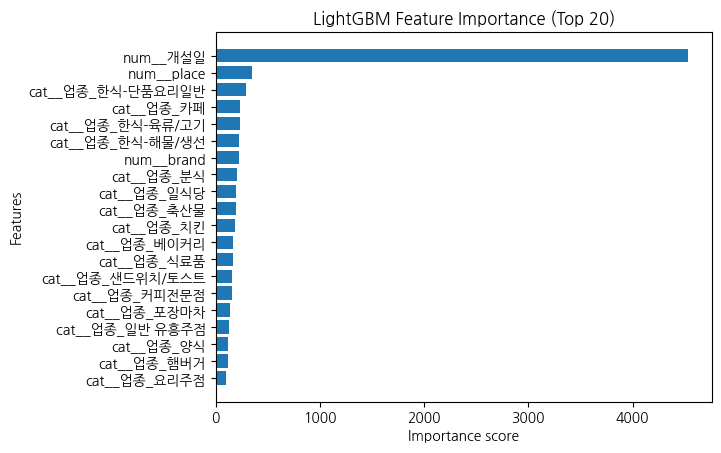

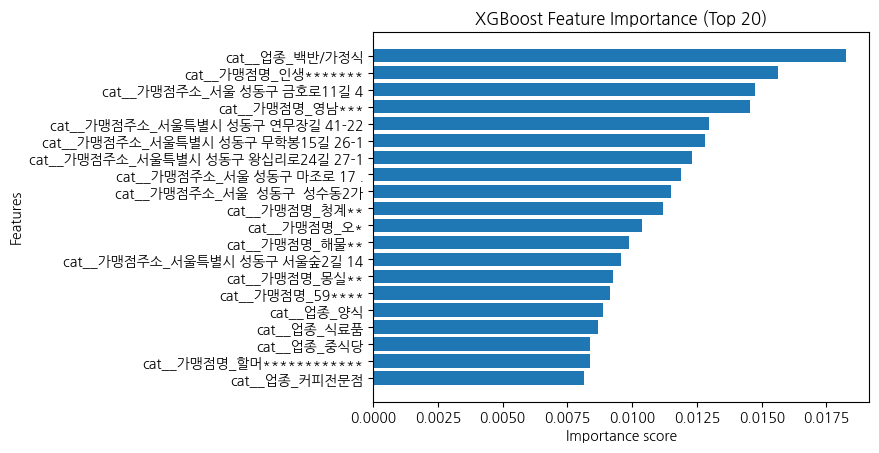

In [17]:
def plot_feature_importance(model_name, features, importances, top_n=20):
    idx = np.argsort(importances)[::-1][:top_n]
    plt.barh(np.array(features)[idx][::-1], np.array(importances)[idx][::-1])
    plt.title(f"{model_name} Feature Importance (Top {top_n})")
    plt.xlabel("Importance score")
    plt.ylabel("Features")
    plt.show()


# LightGBM
fi_lgb = lgb_model.feature_importances_
plot_feature_importance("LightGBM", X_val.columns, fi_lgb)

# XGBoost
fi_xgb = xgb_model.feature_importances_  # numpy array
plot_feature_importance("XGBoost", X_val.columns, fi_xgb)

# CatBoost
# fi_cat = cat_model.get_feature_importance()
# plot_feature_importance("CatBoost", X_val.columns, fi_cat)

In [18]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
    verbose = -1
)

import pandas as pd

fi = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi.head(10))

top_features = fi.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_spl

In [ ]:
result_xgb = permutation_importance(
    xgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
     verbose = -1
)

fi_xgb = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result_xgb.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi_xgb.head(10))

top_features_xgb = fi_xgb.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features_xgb["feature"], top_features_xgb["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

### Deep Learning